In [14]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782678827.log")
assert p.exists()

In [16]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

283499


In [17]:
def extract_animal_data(line):
    # Match new log format: [unix_ts=...] [frame=...] animal_despawn reason=... lifetime_frames=... animal=Animal { ... }
    pat = (
        r".*"
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_timestamp>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"animal_despawn "
        r"reason=(?P<reason>\w+) "
        r"lifetime_frames=(?P<lifetime>\d+) "
        r"animal=Animal\s*\{ "
        r"id:\s*(?P<id>\d+),\s*"
        r"parent_id:\s*Some\((?P<parent_id>\d+|None)\),\s*"
        r"diet:\s*(?P<diet>\w+),\s*"
        r".*"
        r"family:\s*(?P<family>\d+)\s*\}"
        r".*"
    )

    m = re.match(
        pat,
        line,
    )

    if m is not None:
        d = {}
        d["simulation_start_ts"] = m.group("simulation_start_ts")
        d["unix_timestamp"] = float(m.group("unix_timestamp"))
        d["lifetime"] = float(m.group("lifetime"))
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        d["id"] = int(m.group("id"))
        d["parent_id"] = m.group("parent_id")
        return d
    return None


In [18]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [19]:
df

""


In [20]:
sns.barplot(data=df, x="diet", y="lifetime")

ValueError: Could not interpret value `diet` for `x`. An entry with this name does not appear in `data`.

In [21]:
sns.barplot(data=df, x="family", y="lifetime")

ValueError: Could not interpret value `family` for `x`. An entry with this name does not appear in `data`.

# Population

In [22]:
def extract_population_data(line):
    m = re.match(
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_ts>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"population_size "
        r"plants=(?P<plants>\d+) "
        r"animals=\{(?P<animals>[^}]+)\} "
        r"families=(?P<families>\d+:\d+(?:\|\d+:\d+)*)",
        line,
    )
    if m is None:
        return None

    animals = {k: int(v) for k, v in (pair.split(":") for pair in m.group("animals").split())}
    families = [tuple(map(int, f.split(":"))) for f in m.group("families").split("|")]

    return {
        "simulation_start_ts": int(m.group("simulation_start_ts")),
        "unix_ts": int(m.group("unix_ts")),
        "frame": int(m.group("frame")),
        "n_plants": int(m.group("plants")),
        "carnivores": animals.get("carnivores", 0),
        "herbivores": animals.get("herbivores", 0),
        "omnivores": animals.get("omnivores", 0),
        "scavengers": animals.get("scavengers", 0),
        "families": families,
    }


In [23]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
85,1782678827,1782678829,10,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
250,1782678827,1782678832,12,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
251,1782678827,1782678832,13,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
252,1782678827,1782678832,16,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
253,1782678827,1782678832,17,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
...,...,...,...,...,...,...,...,...
1763952,1782678827,1782709375,0,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."
1764025,1782678827,1782709376,1,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."
1764026,1782678827,1782709376,2,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."


### Genetic DIversity

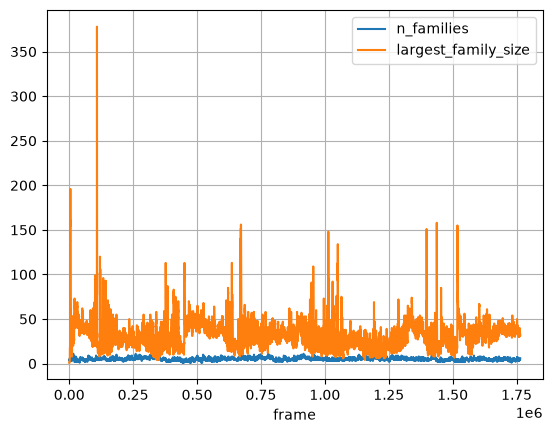

In [24]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

plt.grid(True)

### Population

In [25]:
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
85,1782678827,1782678829,10,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
250,1782678827,1782678832,12,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
251,1782678827,1782678832,13,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
252,1782678827,1782678832,16,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
253,1782678827,1782678832,17,2,1,1,0,"[(0, 1), (1, 1), (2, 1), (1620009494, 1)]"
...,...,...,...,...,...,...,...,...
1763952,1782678827,1782709375,0,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."
1764025,1782678827,1782709376,1,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."
1764026,1782678827,1782709376,2,1,34,0,6,"[(0, 33), (699635045, 1), (1610523608, 4), (21..."


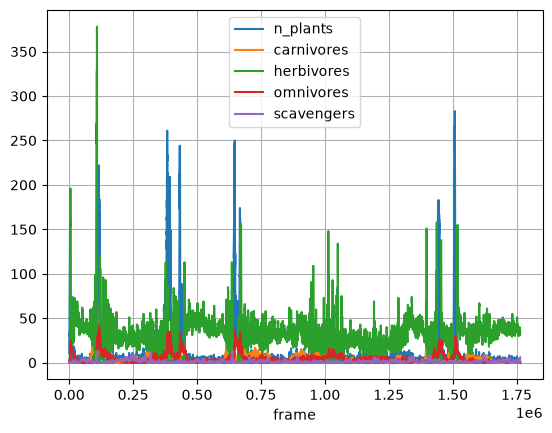

In [26]:
#df["n_plants"].plot()
df[["n_plants","carnivores", "herbivores", "omnivores", "scavengers"]].plot()
plt.grid()
plt.legend()